<a href="https://colab.research.google.com/github/14marcos1/curso_colab_2026/blob/main/DATASUS000001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Célula 1: Instalação das bibliotecas e dependências do DATASUS




In [2]:

!pip install --upgrade pysus pyreaddbc dbfread pandas matplotlib seaborn

  Using cached pandas-3.0.5-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)


# Célula 2: Download do SIM, filtragem de CIDs, Tabela e Gráfico

#Correção

Conectando ao servidor FTP do DATASUS (ftp.datasus.gov.br)...
Conexão estabelecida com sucesso!

-> Ano 2010 baixado com sucesso (3009 registros).
-> Ano 2011 baixado com sucesso (3157 registros).
-> Ano 2012 baixado com sucesso (3293 registros).
-> Ano 2013 baixado com sucesso (3318 registros).
-> Ano 2014 baixado com sucesso (3476 registros).
-> Ano 2015 baixado com sucesso (3517 registros).
-> Ano 2016 baixado com sucesso (3763 registros).
-> Ano 2017 baixado com sucesso (3832 registros).
-> Ano 2018 baixado com sucesso (4094 registros).
-> Ano 2019 baixado com sucesso (4098 registros).
-> Ano 2020 baixado com sucesso (4860 registros).
-> Ano 2021 baixado com sucesso (5496 registros).
-> Ano 2022 baixado com sucesso (4159 registros).
-> Ano 2023 baixado com sucesso (4189 registros).
-> Ano 2024 baixado com sucesso (4267 registros).

=== TABELA DE ÓBITOS POR RESIDÊNCIA (ACRE) ===


/tmp/ipykernel_1404/2601621618.py:73: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_sim['CATEGORIA'] = df_sim['CAUSABAS'].apply(categorizar_causa)


CATEGORIA,Doenças do Sistema Nervoso (Cap. VI),Neoplasias (Cap. II),Total
ANO,,,
2010,50,331,381
2011,43,380,423
2012,57,470,527
2013,64,470,534
2014,55,496,551
2015,65,494,559
2016,67,508,575
2017,60,574,634
2018,87,595,682


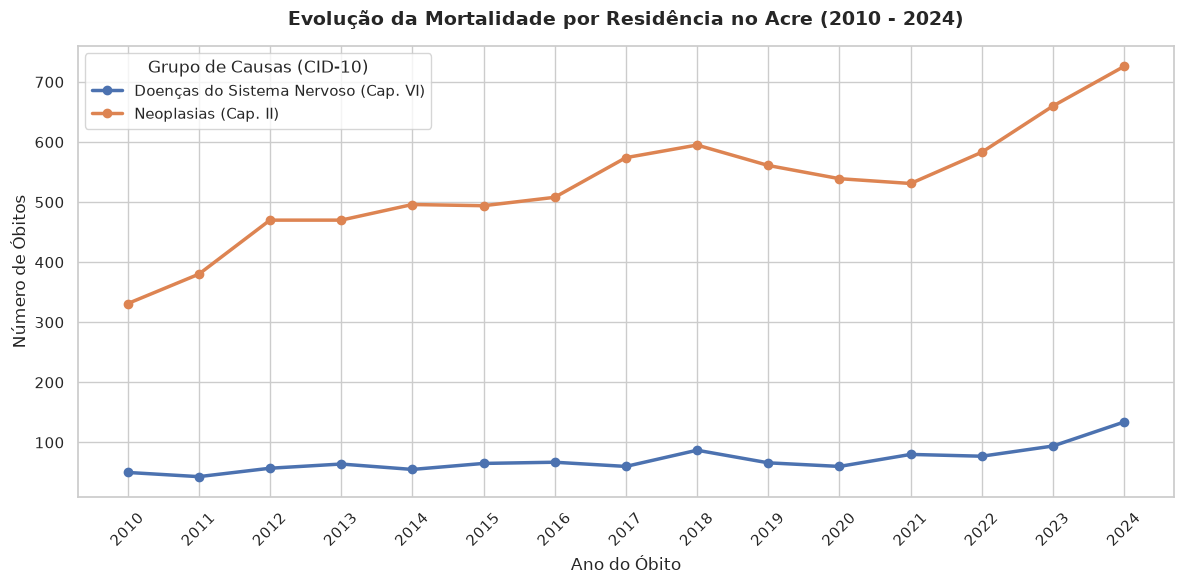

In [7]:
# Célula 2: Download, Tratamento, Tabela e Gráfico
import os
import ftplib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dbfread import DBF
import pyreaddbc

# 1. Configurações gerais
uf = 'AC'
anos = list(range(2010, 2025))

ftp_host = "ftp.datasus.gov.br"
ftp_dir = "/dissemin/publicos/SIM/CID10/DORES/"

dfs = []

print(f"Conectando ao servidor FTP do DATASUS ({ftp_host})...")

try:
    ftp = ftplib.FTP(ftp_host, timeout=60)
    ftp.login()
    ftp.cwd(ftp_dir)
    ftp.set_pasv(True)
    print("Conexão estabelecida com sucesso!\n")

    for ano in anos:
        nome_dbc = f"DO{uf}{ano}.DBC"
        dbf_temp = f"DO{uf}{ano}.dbf"

        try:
            with open(nome_dbc, 'wb') as f:
                ftp.retrbinary(f"RETR {nome_dbc}", f.write)

            pyreaddbc.dbc2dbf(nome_dbc, dbf_temp)
            table = DBF(dbf_temp, encoding='iso-8859-1')
            df_temp = pd.DataFrame(iter(table))

            df_temp['ANO'] = int(ano)
            dfs.append(df_temp)
            print(f"-> Ano {ano} baixado com sucesso ({len(df_temp)} registros).")

            if os.path.exists(nome_dbc): os.remove(nome_dbc)
            if os.path.exists(dbf_temp): os.remove(dbf_temp)

        except Exception as e:
            print(f"-> Falha ao obter o ano {ano}: {e}")
            if os.path.exists(nome_dbc): os.remove(nome_dbc)

    ftp.quit()

except Exception as e:
    print(f"Erro de conexão com o servidor FTP: {e}")

if not dfs:
    raise RuntimeError("Nenhum arquivo pôde ser baixado do DATASUS.")

# 2. Processamento dos Dados
df_sim = pd.concat(dfs, ignore_index=True)

def categorizar_causa(cid):
    if pd.isna(cid):
        return 'Outras'
    cid = str(cid).upper().strip()
    if cid.startswith('G'):
        return 'Doenças do Sistema Nervoso (Cap. VI)'
    elif cid.startswith('C') or (cid.startswith('D') and len(cid) >= 3 and cid[1:3].isdigit() and int(cid[1:3]) <= 48):
        return 'Neoplasias (Cap. II)'
    else:
        return 'Outras'

df_sim['CATEGORIA'] = df_sim['CAUSABAS'].apply(categorizar_causa)

df_filtrado = df_sim[df_sim['CATEGORIA'].isin([
    'Doenças do Sistema Nervoso (Cap. VI)',
    'Neoplasias (Cap. II)'
])].copy()

# 3. Tabela Cruzada
tabela_mortalidade = pd.crosstab(
    df_filtrado['ANO'],
    df_filtrado['CATEGORIA'],
    margins=True,
    margins_name='Total'
)

print("\n=== TABELA DE ÓBITOS POR RESIDÊNCIA (ACRE) ===")
display(tabela_mortalidade)

# 4. Gráfico de Linhas (Conversão nativa de tipos para Python 3.13)
tabela_grafico = tabela_mortalidade.drop(index='Total', columns='Total', errors='ignore')

anos_x = [int(a) for a in tabela_grafico.index]

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

for coluna in tabela_grafico.columns:
    valores_y = tabela_grafico[coluna].astype(int).tolist()
    plt.plot(
        anos_x,
        valores_y,
        marker='o',
        linewidth=2.5,
        label=coluna
    )

plt.title('Evolução da Mortalidade por Residência no Acre (2010 - 2024)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Ano do Óbito', fontsize=12)
plt.ylabel('Número de Óbitos', fontsize=12)
plt.xticks(anos_x, rotation=45)
plt.legend(title='Grupo de Causas (CID-10)', frameon=True)
plt.tight_layout()

plt.show()